In [1]:
import os
os.chdir('/workspace/8c50938a-4e3e-4a69-89c9-0648c02d1679')
print(os.listdir('.'))

['memory', '.prompts', '.kernel_llm_logs_1.txt', '.config', 'ldh_def.py']


In [2]:
import subprocess
print(subprocess.run(['pip','list'], capture_output=True, text=True).stdout[:3000])

Package Version Build
------------------------- ------------ -----
adjustText 1.3.0
aiofiles 25.1.0
aiohappyeyeballs 2.6.1
aiohttp 3.13.3
aiosignal 1.4.0
anndata 0.12.6
annotated-doc 0.0.4
annotated-types 0.7.0
anyio 4.12.1
appdirs 1.4.4
appnope 0.1.4
argon2-cffi 25.1.0
argon2-cffi-bindings 25.1.0
argparse-dataclass 2.0.0
array-api-compat 1.14.0
arrow 1.4.0
asttokens 3.0.1
async-lru 2.2.0
async-timeout 5.0.1
attrs 25.4.0
babel 2.18.0
beartype 0.22.9
beautifulsoup4 4.14.3
biopython 1.86
bioservices 1.13.0
biothings_client 0.4.1
bleach 6.3.0
brokenaxes 0.6.2
bx-python 0.13.0
cattrs 26.1.0
certifi 2026.2.25
cffi 2.0.0
charset-normalizer 3.4.6
chempy 0.10.1
choreographer 1.2.1
click 8.1.8
cloudpickle 3.1.2
colorama 0.4.6
coloredlogs 15.0.1
colorlog 6.10.1
colormap 1.3.0
colormath2 3.0.3
comm 0.2.3
ConfigArgParse 1.7.5
connection_pool 0.0.3
contourpy 1.3.3
coredis 5.7.0
cryptography 46.0.7
cuda-bindings 12.9.4
cuda-pathfinder 1.4.3
cycler 0.12.1
Cython 3.2.4
datasets 4.8.2
datrie 0.8.3
debu

In [3]:
import subprocess
r = subprocess.run(['pip','list'], capture_output=True, text=True).stdout
for line in r.split('\n'):
 if any(p in line.lower() for p in ['cypari','sympy','mpmath','primesieve','sage']):
 print(line)

mpmath 1.3.0
sympy 1.14.0


In [4]:
import subprocess
r = subprocess.run(['pip','install','cypari2','-q'], capture_output=True, text=True)
print(r.stdout[-500:]); print("ERR:", r.stderr[-500:])


ERR: 


In [5]:
import cypari2
pari = cypari2.Pari()
# Quick test: Ramanujan tau coefficients
tau = [int(pari.ramanujantau(n)) for n in range(1,11)]
print(tau)

[1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [6]:

# Plan analysis
# 
# Dirichlet polynomial: D_L(t) = sum_{n=1..N} a_n / n^{1/2 + i t}
# Decompose by omega(n) = number of distinct prime factors:
# S_k(t) = sum_{n: omega(n)=k} a_n / n^{1/2 + i t}, k=0,1,2,...
# (k=0 corresponds to n=1.)
# D_L(t) = sum_k S_k(t)
#
# Fourth moment:
# I = int_0^T |D_L(t)|^4 dt = int |sum_k S_k|^4 dt
# = sum_{j1,k1,j2,k2} int S_{j1}(t) S_{k1}(t) bar(S_{j2}(t)) bar(S_{k2}(t)) dt
#
# Term type A "main pure-class" (k,k,k,k): all four indices equal: sum_k int |S_k|^4 dt
# Term type B "diagonal cross-class" (j,j,k,k) with j != k: 
# indices: {j1,k1} = {j,k}, {j2,k2} = {j,k} (unordered match)
# Effectively, the diagonal cross-class corresponds to terms where the multiset
# {j1,k1} (for S*S) equals {j2,k2} (for S̄*S̄) and {j1,k1} contains two distinct values j!=k.
# Equivalent to: int |S_j|^2 |S_k|^2 dt (for ordered j<k), with combinatorial factor.
# Off-diagonal: everything else.
#
# Closed form for int_0^T S_{j1} S_{k1} bar(S_{j2}) bar(S_{k2}) dt:
# = sum_{n1 (omega=j1)} sum_{n2 (omega=k1)} sum_{m1 (omega=j2)} sum_{m2 (omega=k2)}
# a_{n1} a_{n2} bar(a_{m1}) bar(a_{m2}) / sqrt(n1 n2 m1 m2)
# * int_0^T (n1 n2)^{-it} (m1 m2)^{it} dt
# = sum ... * I_T(n1 n2, m1 m2)
# where I_T(A,B) = int_0^T (B/A)^{it} dt = T if A=B, else (e^{i T log(B/A)} - 1)/(i log(B/A))
#
# So we need to enumerate pairs (n1,n2) with omega = (j1,k1), pairs (m1,m2) with (j2,k2),
# and compute the cross-product sum. We bucket products A = n1*n2 with weighted coefficients.
#
# Let me define, for each pair (j,k) of omega-classes:
# F_{j,k}(A) = sum_{(n1,n2): omega(n1)=j, omega(n2)=k, n1*n2 = A} a_{n1} a_{n2} / sqrt(n1 n2)
# Then int_0^T S_j S_k bar(S_{j'}) bar(S_{k'}) dt 
# = sum_{A,B} F_{j,k}(A) bar(F_{j',k'}(B)) * I_T(A,B)
#
# Total fourth moment = |F_{total}(A)|^2 etc.
#
# For computational tractability: N_terms = 10^4, so we have ~10^8 (n1,n2) pairs.
# Bucketing by product A: A ranges up to N^2 = 10^8. Number of distinct products is ~ N^2 / log(N).
# This is too much memory.
#
# Alternative: full fourth moment factors nicely as |sum_n a_n/sqrt(n) * n^{-it}|^4 
# Let G(t) = D_L(t). Then |G|^4 = |G|^2 * |G|^2. 
# |G(t)|^2 = sum_{n,m} a_n bar(a_m)/sqrt(nm) (m/n)^{it}
# = sum_{n,m} a_n bar(a_m)/sqrt(nm) e^{it log(m/n)}
# So int_0^T |G|^4 dt = int_0^T [sum_{n,m} c_{n,m} e^{it log(m/n)}] [sum_{p,q} c_{p,q} e^{it log(q/p)}] dt
# = sum_{n,m,p,q} c_{n,m} c_{p,q} int_0^T e^{it log(mq/np)} dt
# = sum_{n,m,p,q} c_{n,m} c_{p,q} I_T(np, mq)
# Group by D = mq/np or A=np, B=mq:
# = sum_{A,B} h(A) h(B) I_T(A,B)
# where h(A) = sum_{n,m: nm = A ??? } ... wait this isn't quite right since A=np and B=mq
# 
# Let's re-derive cleanly:
# |G(t)|^2 = G(t) bar(G(t)) = sum_n a_n n^{-1/2} n^{-it} * sum_m bar(a_m) m^{-1/2} m^{it}
# Let phi(t) = |G(t)|^2 = sum_{n,m} (a_n bar(a_m)/sqrt(nm)) (m/n)^{it}
# |G(t)|^4 = phi(t)^2 (since phi is real)
# = sum_{n,m,p,q} (a_n bar(a_m) a_p bar(a_q)/sqrt(nmpq)) (mq/(np))^{it}
# int_0^T |G|^4 dt = sum_{n,m,p,q} (a_n bar(a_m) a_p bar(a_q)/sqrt(nmpq)) I_T(np, mq)
#
# Now decompose by omega: assign each (n,m,p,q) a class quadruple (omega(n),omega(m),omega(p),omega(q)).
# Wait - the natural decomposition by the question is to write G = sum_k S_k, and look at
# G * bar(G) * G * bar(G) = (sum_j S_j) (sum_k bar(S_k)) (sum_l S_l) (sum_r bar(S_r))
# So the quadruple of omega-indices is (omega(n), omega(m), omega(p), omega(q)) = (j, k, l, r)
# where j,l are from "positive" S and k,r are from "conjugate" S.
#
# "Pure-class (k,k,k,k)": all four equal: j=k=l=r.
# "Diagonal cross-class (j,j,k,k)": the multiset {j,k,l,r} = {j,j,k,k}. The question's notation 
# ∫|S_j|² |S_k|² dt corresponds to pairs (S_j)(bar S_j)(S_k)(bar S_k), i.e., 
# indices (omega(n), omega(m), omega(p), omega(q)) where {omega(n),omega(p)} = {j,k} and 
# {omega(m),omega(q)} = {j,k}. With j != k.
#
# This still requires enumerating all 4-tuples, but only for the "pure" and "diagonal" classes.
# For pure (k,k,k,k): restrict n,m,p,q to omega-class k. With N=10^4 and classes ~ up to omega(n)<=5,
# the largest classes have ~few thousand elements => 4-tuples ~ 10^13. Too many.
#
# Use the bucketing trick. For each pair (j_class, k_class) with class for positive index j and 
# negative index k, define
# h_{j,k}(A) = sum_{n,m: omega(n)=j, omega(m)=k, n*m... wait
# Actually let's split differently. Define for class-pair (jl, kr) where jl is positive, kr is negative:
# H_{jl,kr}(A) = sum_{n,m: omega(n)=jl, omega(m)=kr, n*m=A} (a_n bar(a_m)/sqrt(nm))
# Wait we have np in exponent, so the relevant bucket is product np for positive and mq for negative.
# Let me define for each pair (j1,j2) of positive omega-classes:
# P_{j1,j2}(A) = sum_{n,p: omega(n)=j1, omega(p)=j2, n*p = A} a_n a_p / sqrt(n p)
# and for each pair (k1,k2) of negative omega-classes:
# Q_{k1,k2}(B) = sum_{m,q: omega(m)=k1, omega(q)=k2, m*q = B} bar(a_m a_q) / sqrt(m q)
# Note Q_{k1,k2}(B) = conj(P_{k1,k2}(B)) since coefficients can be complex (for L_DH).
# For real coefficients (zeta, Delta), Q = P.
#
# Then the contribution to fourth moment with omega-quadruple (j1, k1, j2, k2):
# (where j1, j2 are positive S indices, k1, k2 are negative)
# M(j1,k1,j2,k2) = int_0^T S_{j1} bar(S_{k1}) S_{j2} bar(S_{k2}) dt
# = sum_{A,B} P_{j1,j2}(A) Q_{k1,k2}(B) I_T(A,B)
# 
# Wait but in my original expansion I had a_n bar(a_m) a_p bar(a_q), corresponding to 
# S_{j1}(t) [from n] * bar(S_{k1})(t) [from m] * S_{j2}(t) [from p] * bar(S_{k2})(t) [from q]
# So omega(n)=j1, omega(m)=k1, omega(p)=j2, omega(q)=k2. Good.
# And exponent (m q / (n p))^{it} groups np vs mq as before.
#
# Total fourth moment = sum over all (j1,k1,j2,k2) of M(j1,k1,j2,k2).
# Equivalently: M_total = sum_{A,B} P_total(A) Q_total(B) I_T(A,B)
# where P_total(A) = sum over (j1,j2) of P_{j1,j2}(A) = sum_{n,p: n p = A} a_n a_p /sqrt(n p)
# and Q_total(B) = conj(P_total(B)).
#
# Pure (k,k,k,k): j1=j2=k1=k2=k. So pick P_{k,k}(A), Q_{k,k}(B).
# Diagonal (j,j,k,k) j!=k: contributions where multiset {j1,j2} as a sorted pair = some pair (a,b),
# and {k1,k2} sorted pair = the same (a,b). With (a,b) = (j,k), j!=k.
# 
# Hmm actually the question says ∫|S_j|² |S_k|² dt = int (S_j bar S_j)(S_k bar S_k) dt.
# (S_j bar S_j)(S_k bar S_k) = S_j S_k bar(S_j) bar(S_k) 
# So this is the (j1,k1,j2,k2) = (j,j,k,k) term, i.e., positive: n is class j, p is class k;
# negative: m is class j, q is class k. j != k. So {j1, j2} = {j, k} with j1=j, j2=k.
# But there are multiple orderings that give the same |S_j|^2 |S_k|^2 product type:
# (j1,k1,j2,k2) ∈ { (j,j,k,k), (j,k,k,j), (k,j,j,k), (k,k,j,j) } all give the same.
# 
# I'll define "diagonal cross-class (j,j,k,k)" as the sum of all these contributions where 
# {j1, j2} (as multiset) = {k1, k2} (as multiset) and the multiset is {j, k} with j != k.
# 
# Let's now build the engine. The bottleneck is computing P_{j1,j2}(A) for all A and (j1,j2).
# With N=10^4, total pairs (n,p) = 10^8. We need to group by product A=n*p, with class-pair (j1,j2).
# Memory: store dict[(j1,j2)] -> dict[A] -> complex.
# 10^8 operations is feasible in pure python? ~10 minutes. Let's use vectorization in numpy.
#
# But we also need P_total(A) for total and difference computation.

print("Plan formulated")

Plan formulated


In [7]:

# Let's think about a more efficient approach.
# Actually since I_T(A, B) only depends on A and B (not on the class pair),
# we can compute it once. 
#
# I_T(A,B) = T if A==B; else (exp(i T log(B/A)) - 1) / (i log(B/A))
#
# Sum over (A,B) of P(A) bar(P(B)) I_T(A,B) -- this is a quadratic form.
#
# The diagonal A=B contribution is T * sum_A |P(A)|^2.
# The off-diagonal is sum_{A != B} P(A) bar(P(B)) (e^{iT log(B/A)}-1)/(i log(B/A)).
#
# The diagonal piece T * sum_A |P(A)|^2 is by far the dominant for large T 
# (this is the "mean square" contribution that doesn't oscillate).
# Off-diagonal terms oscillate and contribute less.
# 
# For ζ (a_n=1), |P_total(A)|^2 = (# pairs (n,p) with np = A, n,p<=N)^2 / (n p), 
# weighted: P_total(A) = sum_{n p = A, n,p<=N} 1/sqrt(np) = (1/sqrt(A)) * d(A; N) where 
# d(A; N) = # of divisor pairs with both <=N. So |P_total(A)|^2 = d(A;N)^2 / A.
# T*sum_A |P|^2 = T * sum_A d(A;N)^2 / A.
# 
# This is the diagonal approximation to the 4th moment! Good consistency check.

# Implementation strategy:
# Step 1: For each L-function, compute coefficients a_n for n=1..N=10^4.
# Step 2: Compute omega(n) for n=1..N.
# Step 3: For each pair of positive classes (j1, j2), compute 
# P_{j1,j2}(A) = sum over (n,p) with omega(n)=j1, omega(p)=j2, n*p=A of a_n a_p / sqrt(n p)
# (note: positive vs negative S — the conjugate makes Q_{k1,k2}(A) = conj(P_{k1,k2}(A)))
# Step 4: Compute I_T(A,B) and the quadratic form. 
# Use full quadratic form with all (A,B) — but A,B can be up to 10^8.
# 
# Hmm 10^8 distinct products is huge. But for N=10^4, the number of distinct products 
# of pairs from [1,N] is at most ~N^2/something. Need to check.
# 
# Actually we can split P_total(A) = sum over class pairs. Let me think about the diagonal A=B
# contribution first, since that's the dominant T-scaling piece. Maybe we focus on the
# DIAGONAL fourth moment (A=B) for fractional contribution analysis. The off-diagonal is 
# T-independent in the limit (smaller correction).
# 
# The DIAGONAL 4th moment: I_diag = T * sum_A |P_total(A)|^2 
# = T * sum_A |sum_{(j1,j2)} P_{j1,j2}(A)|^2
# = T * sum_{j1,j2,j2',j2''} sum_A P_{j1,j2}(A) bar(P_{j1'',j2''}(A))... 
# wait, we need both class quadruple decomposition AND the A=B selection.
# 
# Actually let's do the full computation including off-diagonal. The fractional contributions
# are with respect to TOTAL fourth moment, so we need the total int_0^T |D_L|^4 dt and the 
# decomposition.

# An alternative implementation: numerical integration!
# Just numerically compute D_L(t) at many sample points t in [0,T], then sum |D_L|^4 weights.
# And similarly sum |S_k|^4, |S_j|^2 |S_k|^2 at the same sample points.
# This is MUCH simpler.
# 
# Quadrature: T=500, need enough samples. The integrand oscillates at frequency ~log(N^2) ~ 18.
# Nyquist: 18/(2pi) ~ 3 oscillations per unit t. So dt ~ 0.1 might be too coarse. Use dt ~ 0.01,
# i.e., 50000 sample points. Per sample: compute S_k(t) for k=0..max_omega (~5 classes), 
# each is sum over up to 10^4 terms. Per sample cost ~ 10^4 * 5 = 5*10^4. Total ops: 2.5*10^9.
# Slow but feasible with numpy vectorization.
#
# Actually, we can vectorize: S_k(t) = sum_n a_n / n^{1/2+it} for n in class k.
# At a vector of times: S_k[t_i] = sum_n (a_n / sqrt(n)) * exp(-i t_i log n)
# Compute for all t_i, all n in class k. Stack as matrix product.
#
# Let's evaluate cost: M = 50000 samples, N = 10^4 terms. Per L-function:
# - Compute D = exp(-i * t_vec.outer(log_n_vec)) shape (M, N): 5*10^8 complex multiplications. ~50 sec.
# - Multiply by coefs and sum per class to get S_k: matrix-vector products. 
# - Then evaluate |D|^4 etc.
# Memory: 5*10^8 * 16 bytes = 8 GB. Too much.
# 
# Better: chunk by time. Process M=50000 in chunks of 1000 samples. Per chunk: 1000*10^4 = 10^7 entries (160 MB). 
# Doable.
# 
# Best approach: numerical integration via chunked time sampling.

# Now think about quadrature: ∫_0^T |D|^4 dt. Use trapezoid with dt=0.01 (50000 intervals).
# Actually using Simpson's rule and verifying convergence.

# Number of samples needed: D_L(t) oscillates at frequencies log(n/m), max ~log(N) ~ 9.2.
# So fastest frequency is ~9.2/(2pi) ~ 1.5 Hz. For accurate quadrature, ~50 samples per oscillation.
# So dt ~ 1/75 ~ 0.013. T=500 => 37500 samples. Let's use dt=0.01, 50000 samples.

# Set up and verify with a small case first.
import numpy as np

N_terms = 10000
T = 500.0
dt = 0.01

n_arr = np.arange(1, N_terms+1)
log_n = np.log(n_arr)
print(f"N={N_terms}, T={T}, dt={dt}, max freq= {log_n.max():.4f}, periods at maxfreq: {T*log_n.max()/(2*np.pi):.0f}")

N=10000, T=500.0, dt=0.01, max freq= 9.2103, periods at maxfreq: 733


In [8]:

# Compute omega(n) = number of distinct prime factors
import sympy

def omega(n):
 if n == 1:
 return 0
 return len(sympy.factorint(n))

omega_arr = np.array([omega(n) for n in n_arr], dtype=np.int8)
print("omega counts:", np.bincount(omega_arr))
print("max omega:", omega_arr.max())
classes = sorted(set(omega_arr.tolist()))
print("classes:", classes)

omega counts: [ 1 1280 4097 3695 894 33]
max omega: 5
classes: [0, 1, 2, 3, 4, 5]


In [9]:

# Compute coefficients for each L-function up to N=10000
# 1. zeta: a_n = 1 for all n
# 2. L(Delta): a_n = tau(n) * n^{-11/2} (normalized to critical line s=1/2)
# Ramanujan's L(s, Delta) = sum tau(n) n^{-s-(k-1)/2} where k=12, so normalized: 
# L(s + 11/2, Delta_raw) shifted to critical line at s=1/2. So a_n = tau(n)/n^{11/2}.
# 3. L_DH: a_n = A * chi(n) + B * chi_bar(n), period 5
# chi(n) = [0, 1, i, -i, -1][n mod 5]
# Actually L_DH(s) = A * L(s, chi) + B * L(s, chi_bar) = sum_n (A chi(n) + B chi_bar(n))/n^s
# so a_n = A chi(n) + B chi_bar(n).
# For chi mod 5 of order 4: chi(0)=0, chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1.

# Coefficients for zeta
a_zeta = np.ones(N_terms, dtype=np.complex128)

# Coefficients for L(Delta): use cypari2 ramanujantau
print("Computing tau(n)...")
tau = np.zeros(N_terms, dtype=np.float64)
for i in range(N_terms):
 tau[i] = float(pari.ramanujantau(int(i+1)))
# normalized coefficients
n_arr_f = n_arr.astype(np.float64)
a_delta = tau / n_arr_f**5.5
a_delta = a_delta.astype(np.complex128)
print("a_delta[:5]:", a_delta[:5])
print("range:", a_delta.real.min(), a_delta.real.max())

# Coefficients for L_DH
import mpmath
mpmath.mp.dps = 50
SQRT5 = mpmath.sqrt(5)
XI_DH = (mpmath.sqrt(10 - 2*SQRT5) - 2) / (SQRT5 - 1)
xi = float(XI_DH)
A_c = (1 - 1j*xi)/2
B_c = (1 + 1j*xi)/2
chi_vals = {1: 1+0j, 2: 1j, 3: -1j, 4: -1+0j, 0: 0+0j}
chi_bar_vals = {1: 1+0j, 2: -1j, 3: 1j, 4: -1+0j, 0: 0+0j}
a_ldh = np.zeros(N_terms, dtype=np.complex128)
for i in range(N_terms):
 n = i+1
 r = n % 5
 a_ldh[i] = A_c * chi_vals[r] + B_c * chi_bar_vals[r]
print("a_ldh[:6]:", a_ldh[:6])
# Check: a_ldh[0] = A + B = 1
# a_ldh[1] = A*i + B*(-i) = i(A-B) = i*(-i*xi) = xi -- real
# a_ldh[2] = A*(-i) + B*i = i*(B-A) = i*(i*xi) = -xi -- real
# a_ldh[3] = A*(-1)+B*(-1) = -1
# a_ldh[4] = 0
# So a_ldh is REAL. Good (L_DH has real Dirichlet coefficients).

Computing tau(n)...
a_delta[:5]: [ 1. +0.j -0.53033009+0.j 0.59873361+0.j -0.71875 +0.j
 0.69121333+0.j]
range: -3.2795832546365533 2.8050499352418363
a_ldh[:6]: [ 1. +0.j 0.28407904+0.j -0.28407904+0.j -1. +0.j
 0. +0.j 1. +0.j]


In [10]:

# Good. Now build the time-sampling fourth moment engine.
# Use a chunked approach for memory.

def compute_S_classes(coefs, log_n, omega_arr, t_chunk, sqrt_n):
 """
 Compute S_k(t) for each class k at all times in t_chunk.
 Returns dict {k: array of complex of shape (len(t_chunk),)}
 
 S_k(t) = sum_{n: omega(n)=k} a_n / sqrt(n) * exp(-i t log n)
 """
 # Vectorize: form matrix exp(-i * t_chunk[:, None] * log_n[None, :])
 # Multiply by coefs / sqrt(n)
 # Then sum per class.
 # Actually, easier: for each class, slice and sum.
 coefs_norm = coefs / sqrt_n
 result = {}
 # Precompute phases for this chunk
 # phases shape (T_chunk, N) -- memory ~ T_chunk * N * 16 bytes
 # For T_chunk=200, N=10^4: 200*10^4*16 = 32 MB. Good.
 phases = np.exp(-1j * np.outer(t_chunk, log_n)) # (Tc, N)
 for k in classes:
 mask = (omega_arr == k)
 # S_k[i] = sum over n in class k of coefs_norm[n] * phases[i,n]
 result[k] = phases[:, mask] @ coefs_norm[mask]
 return result

# Test
sqrt_n = np.sqrt(n_arr_f)
t_test = np.array([0.0, 1.0, 2.0])
S_zeta = compute_S_classes(a_zeta, log_n, omega_arr, t_test, sqrt_n)
print("D(0) sum class:", sum(S_zeta[k] for k in classes))
# Verify: at t=0, sum should equal sum 1/sqrt(n) for n=1..10000
expected = np.sum(1/sqrt_n)
print("Expected D(0) = sum 1/sqrt(n) =", expected)

D(0) sum class: [198.54464545 +0.j -21.92096361-87.40277922j
 -8.42500568+47.37966138j]
Expected D(0) = sum 1/sqrt(n) = 198.54464544952376


In [11]:

# Great, matches. Now build the moment decomposition.
# 
# For each L-function, at every sample time:
# Compute S_k(t) for k in classes.
# Compute:
# - total: D = sum_k S_k. |D|^4.
# - pure (k,k,k,k): |S_k|^4 for each k. Sum over k.
# - diagonal cross-class (j,j,k,k) j != k: |S_j|^2 |S_k|^2 with appropriate factor.
# 
# Define:
# M_total(t) = |D(t)|^4
# M_pure(t) = sum_k |S_k(t)|^4
# M_diag_cross(t) = sum_{j != k} |S_j(t)|^2 |S_k(t)|^2 
# = (sum_j |S_j|^2)^2 - sum_k |S_k|^4
# = |sum_k |S_k|^2|^2 ... no wait
# sum_{j,k all pairs} |S_j|^2 |S_k|^2 = (sum_k |S_k|^2)^2
# So sum_{j!=k} = (sum |S_k|^2)^2 - sum |S_k|^4
# 
# Note the "diagonal cross-class (j,j,k,k)" in the question is the contribution from
# the omega-quadruple (j,j,k,k) (and permutations giving the same |S_j|^2|S_k|^2).
# As an integral piece of |D|^4, this is the term from expanding |sum S_k|^4 that 
# gives ONLY the products of the form |S_j|^2 |S_k|^2.
# 
# Let's verify: |sum_k S_k|^4 = (sum_k S_k)^2 (sum_k bar S_k)^2 
# = (sum_{j,j'} S_j S_{j'}) (sum_{k,k'} bar S_k bar S_{k'})
# = sum_{j,j',k,k'} S_j S_{j'} bar S_k bar S_{k'}
# So 4-tuple is (j, j', k, k') where j,j' are "positive" indices and k,k' are "negative".
# Question's notation:
# - (k,k,k,k): all four equal. Contribution: |S_k|^4. Sum: sum_k |S_k|^4.
# - (j,j,k,k) j != k: positive pair (j,j) and negative pair (k,k). Contribution: 
# S_j^2 bar(S_k)^2 = S_j^2 (bar S_k)^2. NOT |S_j|^2 |S_k|^2 directly!
# Hmm. Reading the question's wording: "∫|S_j|² |S_k|² dt (diagonal cross-class)" 
# — this hints the diagonal cross-class IS the |S_j|^2 |S_k|^2 contribution.
# 
# Resolving: the "diagonal cross-class (j,j,k,k)" notation probably means contributions 
# where the multiset {positive indices} = {negative indices} = {j,k} (so that pairing 
# can give a |S_j|^2 |S_k|^2 structure). Off-diagonal would be those where the multisets 
# don't match (oscillatory). Let me reinterpret.
# 
# The 4-tuples (j1, j2, k1, k2) — where j1,j2 are positive, k1,k2 are negative — split as:
# (a) "pure": all four equal: j1=j2=k1=k2. Contributes S_k^2 bar(S_k)^2 = |S_k|^4.
# (b) "diagonal": multiset {j1,j2} = multiset {k1,k2}, i.e., positive pair and negative pair 
# are the same. Then S_{j1} S_{j2} bar S_{k1} bar S_{k2} = S_a S_b bar S_a bar S_b = |S_a|^2 |S_b|^2 
# (after pairing). With combinatorial weight 4 for j1 != j2 (and pure subsumed when a=b).
# Or if {j1,j2} = {a,b} sorted, the relevant (j1,j2) choices are (a,b) and (b,a), and similarly 
# (k1,k2) ∈ {(a,b),(b,a)}, giving 2*2=4 ordered combinations all yielding the same |S_a|^2 |S_b|^2.
# So diagonal cross-class (j,j,k,k) j != k contribution = 4 |S_j|^2 |S_k|^2 (for j<k) or 
# 2*sum_{j!=k} |S_j|^2|S_k|^2 = (sum_k |S_k|^2)^2 - sum_k |S_k|^4 ... wait
# sum over all ordered pairs (j1,j2,k1,k2) with multiset positive = multiset negative = {j,k}:
# if j=k (pure): contributes |S_k|^4 (one 4-tuple). 
# if j != k: contributes 4 |S_j|^2 |S_k|^2 (4 4-tuples).
# Total diagonal (including pure) = sum_k |S_k|^4 + 4 * sum_{j<k} |S_j|^2 |S_k|^2.
# (sum_k |S_k|^2)^2 = sum_k |S_k|^4 + 2 sum_{j<k} |S_j|^2 |S_k|^2
# So 4*sum_{j<k} |S_j|^2|S_k|^2 = 2 * [(sum_k |S_k|^2)^2 - sum_k |S_k|^4]
# And total diagonal = sum_k|S_k|^4 + 2(sum_k |S_k|^2)^2 - 2 sum_k|S_k|^4 = 2(sum_k|S_k|^2)^2 - sum_k|S_k|^4
# 
# (c) "off-diagonal": multiset {j1,j2} ≠ multiset {k1,k2}. Oscillatory.
# 
# The pointwise pieces aren't separately positive though (off-diagonal can be complex), but 
# their TIME INTEGRALS are well-defined and the "diagonal" piece is the non-oscillatory part.
# 
# Actually since |D|^4 is real and positive, and the decomposition is by class-tuple:
# |D|^4 = sum_{j1,j2,k1,k2} S_{j1} S_{j2} bar S_{k1} bar S_{k2}
# Each pointwise summand can be complex; only the total is real positive. The integrals 
# may also be complex individually but the sum is real.
# 
# Let's just compute the time integrals of:
# I_total = int |D|^4 dt
# I_pure(k) = int |S_k|^4 dt (real, nonneg)
# I_cross(j,k) for j!=k = int |S_j|^2 |S_k|^2 dt (real, nonneg)
# 
# I'll define the "diagonal cross-class contribution" as 
# I_diag_cross_total = 4 * sum_{j<k} I_cross(j,k) 
# (since this is the coefficient in the expansion). Actually let me just present the 
# fractions of each kind. The question says:
# "fractions of the total fourth moment contributed by the main pure-class (k,k,k,k) and 
# diagonal cross-class (j,j,k,k) terms"
# 
# Interpretation: "main pure-class" = sum of (k,k,k,k) terms for all k = sum_k int |S_k|^4 dt.
# "diagonal cross-class" = sum of (j,j,k,k) terms for j != k:
# per the expansion, the 4 ordered 4-tuples (j1,j2,k1,k2) ∈ {(j,j,k,k),(j,k,j,k),(j,k,k,j),... }
# wait, the notation (j,j,k,k) with j positive-positive and k negative-negative means 
# positive pair = (j,j), negative pair = (k,k). The other "non-pure diagonals" would be 
# (j,k,j,k) — positive=(j,k), negative=(j,k) — which gives S_j S_k bar S_j bar S_k = |S_j|^2 |S_k|^2.
# 
# The question's notation lumps these together as "diagonal cross-class".
# So "diagonal cross-class" = sum of all 4-tuples where positive multiset = negative multiset 
# (excluding the pure all-equal case). Total time integral of these = 4 * sum_{j<k} I_cross(j,k).
# 
# Let me just compute and present both quantities and the total.

print("Decomposition plan finalized")

Decomposition plan finalized


In [12]:

# Implement the engine. Need to integrate over t in [0, T=500].
# Use Simpson's rule with M points. M=50001 gives dt=0.01.
# Per chunk of 200 samples, compute S_k vectors then accumulate integrands.

def fourth_moment_decomp(coefs, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.01, chunk=200):
 t_arr = np.arange(0, T+dt/2, dt)
 M_samp = len(t_arr)
 coefs_norm = coefs / sqrt_n
 
 # Accumulators (Simpson's coefficients later)
 I_total = np.zeros(M_samp, dtype=np.float64) # |D|^4
 I_pure = {k: np.zeros(M_samp) for k in classes} # |S_k|^4
 I_cross = {} # (j, k) j<k: |S_j|^2 |S_k|^2
 for i, j in enumerate(classes):
 for k in classes[i+1:]:
 I_cross[(j, k)] = np.zeros(M_samp)
 
 # Precompute masks
 mask = {k: (omega_arr == k) for k in classes}
 coefs_class = {k: coefs_norm[mask[k]] for k in classes}
 log_n_class = {k: log_n[mask[k]] for k in classes}
 
 # Chunked
 for start in range(0, M_samp, chunk):
 end = min(start + chunk, M_samp)
 t_chunk = t_arr[start:end]
 Sk = {}
 for k in classes:
 phases = np.exp(-1j * np.outer(t_chunk, log_n_class[k])) # (Tc, Nk)
 Sk[k] = phases @ coefs_class[k] # (Tc,)
 D = sum(Sk[k] for k in classes)
 absD2 = (D * D.conj()).real
 I_total[start:end] = absD2 * absD2
 for k in classes:
 absSk2 = (Sk[k] * Sk[k].conj()).real
 I_pure[k][start:end] = absSk2 * absSk2
 for i, j in enumerate(classes):
 absSj2 = (Sk[j] * Sk[j].conj()).real
 for kk in classes[i+1:]:
 absSk2 = (Sk[kk] * Sk[kk].conj()).real
 I_cross[(j, kk)][start:end] = absSj2 * absSk2
 
 # Integrate via Simpson's rule
 from scipy.integrate import simpson
 int_total = simpson(I_total, x=t_arr)
 int_pure = {k: simpson(I_pure[k], x=t_arr) for k in classes}
 int_cross = {key: simpson(I_cross[key], x=t_arr) for key in I_cross}
 
 return int_total, int_pure, int_cross

# Small test first
import time
print("Testing with T=10, dt=0.01...")
t0 = time.time()
tot, pur, cr = fourth_moment_decomp(a_zeta, log_n, omega_arr, sqrt_n, classes, T=10.0, dt=0.01)
print(f"Time: {time.time()-t0:.1f}s")
print(f"int |D|^4 dt = {tot:.4e}")
print("Pure:", {k: f"{v:.3e}" for k,v in pur.items()})
print("Cross:", {k: f"{v:.3e}" for k,v in cr.items()})
sum_pure = sum(pur.values())
sum_cross_total = 4 * sum(cr.values()) # combinatorial factor 4
print(f"Sum pure: {sum_pure:.4e} ({100*sum_pure/tot:.2f}%)")
print(f"Sum diag cross (×4): {sum_cross_total:.4e} ({100*sum_cross_total/tot:.2f}%)")
print(f"Sum pure + diag cross: {sum_pure + sum_cross_total:.4e} ({100*(sum_pure+sum_cross_total)/tot:.2f}%)")

Testing with T=10, dt=0.01...


Time: 1.3s
int |D|^4 dt = 6.2774e+08
Pure: {0: '1.000e+01', 1: '3.119e+05', 2: '2.161e+07', 3: '1.005e+07', 4: '2.692e+04', 5: '4.736e-02'}
Cross: {(0, 1): '5.431e+02', (0, 2): '5.195e+03', (0, 3): '4.189e+03', (0, 4): '2.637e+02', (0, 5): '4.601e-01', (1, 2): '2.523e+06', (1, 3): '1.616e+06', (1, 4): '7.540e+04', (1, 5): '8.169e+01', (2, 3): '1.440e+07', (2, 4): '6.919e+05', (2, 5): '7.677e+02', (3, 4): '5.055e+05', (3, 5): '5.882e+02', (4, 5): '3.369e+01'}
Sum pure: 3.2002e+07 (5.10%)
Sum diag cross (×4): 7.9313e+07 (12.63%)
Sum pure + diag cross: 1.1132e+08 (17.73%)


In [13]:

# So pure + diag cross account for ~17.7% — most of the contribution must come from 
# (j,k,j,k) and (j,k,k,j) type terms that pair as |S_j|^2|S_k|^2 too! Let me check.
# 
# Actually I think the combinatorial factor for "diagonal cross-class" should be larger.
# 
# Reading the question carefully:
# "diagonal cross-class (j,j,k,k) terms: ∫|S_j|² |S_k|² dt"
# So the question defines the diagonal cross-class as the integral ∫|S_j|² |S_k|² dt directly.
# It might NOT include the combinatorial factor of 4 from the (j1,j2,k1,k2) expansion.
# 
# Let me recompute that interpretation: 
# "diagonal cross-class contribution" = sum_{j != k} int |S_j|^2 |S_k|^2 dt (as defined)
# = 2 * sum_{j<k} int |S_j|^2 |S_k|^2 dt
# 
# Or maybe it means sum_{j < k} (just unordered pairs).
# 
# Actually note an identity: 
# |D|^2 = |sum_k S_k|^2 = sum_{j,k} S_j bar S_k = sum_k |S_k|^2 + 2 Re sum_{j<k} S_j bar S_k
# |D|^4 = (|D|^2)^2 
# = (sum_k |S_k|^2)^2 + cross terms
# = sum_k |S_k|^4 + 2 sum_{j<k} |S_j|^2 |S_k|^2 + cross terms
# 
# So if we look at |D|^4 pointwise, the "diagonal" decomposition of (sum_k|S_k|^2)^2 part is:
# sum_k |S_k|^4 + 2 sum_{j<k} |S_j|^2|S_k|^2
# 
# So the natural combinatorial factor for cross-class is 2 (not 4). Let me reconsider.
# 
# (sum_k |S_k|^2)^2 = (sum_k S_k bar S_k)^2 
# Expand: sum_{j,k} (S_j bar S_j)(S_k bar S_k) -- this gives 4-tuple structure 
# (j, k, j, k) where positive indices are (j, k) and negative indices are (j, k). 
# So this is the 4-tuple (j,k,j,k). Per my earlier analysis these are different from the 
# (j,j,k,k) type. 
# 
# Hmm. The question's notation "(j,j,k,k)" specifically picks ONE arrangement. Let me re-read.
# 
# "diagonal cross-class: ∫|S_j|² |S_k|² dt"
# 
# I think the cleanest interpretation: the question defines THREE categories of terms 
# in the full ∫|D|^4 dt expansion:
# (A) pure-class: from 4-tuples (k,k,k,k), giving ∫|S_k|^4 dt.
# (B) diagonal cross-class: from 4-tuples where positive index multiset = negative index multiset 
# (but not all-equal); equivalently, the time-INTEGRAL is non-vanishing because exponential 
# phase cancels. These split as ∫|S_j|² |S_k|² dt up to combinatorial factors.
# (C) off-diagonal: positive multiset ≠ negative multiset; oscillatory.
# 
# The natural combinatorial expansion of |D|^4 = (D)(D)(bar D)(bar D):
# |D|^4 = sum_{j1, j2, k1, k2} S_{j1} S_{j2} bar S_{k1} bar S_{k2}
# 
# Group by sorted positive multiset M+ = sort(j1,j2) and sorted negative multiset M-= sort(k1,k2):
# (A) M+ = M- = (k,k): the only 4-tuple is (k,k,k,k). Contribution: S_k^2 bar(S_k)^2 = |S_k|^4.
# (B) M+ = M- = (j,k) with j<k: 4-tuples have (j1,j2) ∈ {(j,k),(k,j)} and (k1,k2) ∈ {(j,k),(k,j)}.
# 4 ordered 4-tuples, all giving S_j S_k bar S_j bar S_k = |S_j|^2 |S_k|^2.
# Pointwise contribution = 4 |S_j|^2 |S_k|^2.
# (C) M+ ≠ M-: oscillatory.
# 
# So in the |D|^4 expansion the diagonal cross-class contribution is 4 * sum_{j<k} |S_j|^2|S_k|^2.
# Total of categories A and B: sum_k |S_k|^4 + 4 sum_{j<k}|S_j|^2|S_k|^2.
# 
# However, this is NOT equal to (sum_k|S_k|^2)^2 — that quantity equals sum_k|S_k|^4 + 2 sum_{j<k}|S_j|^2|S_k|^2.
# So pointwise: A + B = 2(sum_k|S_k|^2)^2 - sum_k|S_k|^4. 
# 
# Note (sum|S_k|^2)^2 ≤ |D|^4 ≤ (sum|S_k|)^4 but the diagonal A+B may exceed (sum|S_k|^2)^2.
# 
# Going with this interpretation (combinatorial factor 4 for cross-class), at T=10:
# A = 5.10%, B = 12.63% (×4). Together 17.73%. So off-diagonal (C) = ~82% at T=10. 
# That's a LOT for off-diagonal. But T=10 is small; at T=500 the off-diagonal oscillations should 
# largely cancel.
# 
# Let's run the full calc.

print("Running full calculation T=500 for zeta...")
t0 = time.time()
tot_z, pur_z, cr_z = fourth_moment_decomp(a_zeta, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.01, chunk=200)
print(f"Time: {time.time()-t0:.1f}s")
print(f"int |D|^4 dt = {tot_z:.4e}")
sum_pure_z = sum(pur_z.values())
sum_cross_z = sum(cr_z.values()) 
print(f"Sum pure (k,k,k,k): {sum_pure_z:.4e} ({100*sum_pure_z/tot_z:.3f}%)")
print(f"4 * Sum cross (j!=k, combinatorial): {4*sum_cross_z:.4e} ({100*4*sum_cross_z/tot_z:.3f}%)")
print(f"Pure + cross diagonals: {100*(sum_pure_z + 4*sum_cross_z)/tot_z:.3f}%")
print(f"Off-diagonal (residual): {100*(1 - (sum_pure_z + 4*sum_cross_z)/tot_z):.3f}%")

Running full calculation T=500 for zeta...


Time: 25.2s
int |D|^4 dt = 6.2782e+08
Sum pure (k,k,k,k): 3.2019e+07 (5.100%)
4 * Sum cross (j!=k, combinatorial): 7.9372e+07 (12.642%)
Pure + cross diagonals: 17.742%
Off-diagonal (residual): 82.258%


In [14]:

# Wait — the result at T=500 is essentially the same fractional pattern as at T=10. 
# That doesn't match my expectation that off-diagonal would cancel at large T.
# Let me check: ∫_0^T |D|^4 dt grows like T * (asymptotic 4th moment density). 
# Going from T=10 to T=500: ratio 50. tot went from 6.28e8 to 6.28e8 — wait the scale at T=10 was 
# 6.27e8, at T=500 is 6.28e8?? Let me recheck...
# 
# Oh wait, no — I think I made an error. Look: at T=10 tot=6.2774e+08, at T=500 tot=6.2782e+08.
# Almost identical. That CANNOT be right — must be I integrated to T=10 last time, used wrong T?
# Or there's a bug. Let me re-examine my function.

# Actually I think this is because at T=10 the function went through one big "spike" that 
# dominated the integral. Let me check by sampling D at a few points.
t_arr = np.arange(0, 500+0.005, 0.01)
print("t_arr len:", len(t_arr), "first:", t_arr[0], "last:", t_arr[-1])
# Looks correct.
# 
# But how can int_0^500 |D|^4 dt ≈ int_0^10 |D|^4 dt ??
# That would mean |D|^4 is concentrated near t=0 (which makes sense, D(0) ≈ 198, so |D(0)|^4 ≈ 1.5e9, 
# but the integrand for t>0 should also contribute).
# 
# Mean square of D for zeta with N=10^4: by standard mean-value theorem,
# (1/T) int_0^T |D|^2 dt ≈ sum 1/n ≈ log(N) ≈ 9.2. So |D|^2 ~ 9 on average.
# Then |D|^4 ~ ~3*9^2 = 243 (4th moment of zeta partial sum).
# int_0^500 |D|^4 dt ≈ 500 * 243 = 1.2e5. NOT 6.3e8.
# 
# So my integrand near t=0 has a huge spike that dominates. Let me check.
S_test = compute_S_classes(a_zeta, log_n, omega_arr, np.array([0.0, 1.0, 5.0]), sqrt_n)
D_test = sum(S_test[k] for k in classes)
print("D values:", D_test)
print("|D|^4:", (np.abs(D_test))**4)

t_arr len: 50001 first: 0.0 last: 500.0
D values: [198.54464545 +0.j -21.92096361-87.40277922j
 17.14354986-10.9818422j ]
|D|^4: [1.55393453e+09 6.59307373e+07 1.71812041e+05]


In [15]:

# I see: |D(0)|^4 ≈ 1.55e9, |D(1)|^4 ≈ 6.6e7, |D(5)|^4 ≈ 1.7e5.
# So the spike near t=0 contributes ~1.55e9 * (effective width). 
# Width of central spike ~ 1/log(N) ~ 0.1.
# So central peak ~ 1.55e9 * 0.1 = 1.55e8. Plus tail.
# Means int|D|^4 dt is dominated by the central peak.
# This is a known issue: Dirichlet polynomials sum_{n=1}^N 1/n^{1/2+it} have a big peak at t=0.
# 
# The asymptotic 4th moment formula sum_A d(A;N)^2 / A * T tells the LARGE-T behavior; for T=500 with N=10^4, we are not in that regime.
# 
# Let me check int_10^500 |D|^4 dt to see the smooth-region contribution.

def int_in_range(coefs, log_n, omega_arr, sqrt_n, classes, t_start, t_end, dt=0.01, chunk=200):
 t_arr = np.arange(t_start, t_end + dt/2, dt)
 M_samp = len(t_arr)
 coefs_norm = coefs / sqrt_n
 mask = {k: (omega_arr == k) for k in classes}
 coefs_class = {k: coefs_norm[mask[k]] for k in classes}
 log_n_class = {k: log_n[mask[k]] for k in classes}
 Itot = np.zeros(M_samp)
 Ipure = {k: np.zeros(M_samp) for k in classes}
 Icross = {(j,k): np.zeros(M_samp) for i, j in enumerate(classes) for k in classes[i+1:]}
 for start in range(0, M_samp, chunk):
 end = min(start+chunk, M_samp)
 tc = t_arr[start:end]
 Sk = {}
 for k in classes:
 phases = np.exp(-1j * np.outer(tc, log_n_class[k]))
 Sk[k] = phases @ coefs_class[k]
 D = sum(Sk[k] for k in classes)
 absD2 = (D*D.conj()).real
 Itot[start:end] = absD2*absD2
 for k in classes:
 a2 = (Sk[k]*Sk[k].conj()).real
 Ipure[k][start:end] = a2*a2
 for i, j in enumerate(classes):
 a2j = (Sk[j]*Sk[j].conj()).real
 for kk in classes[i+1:]:
 a2k = (Sk[kk]*Sk[kk].conj()).real
 Icross[(j,kk)][start:end] = a2j*a2k
 from scipy.integrate import simpson
 Itot_v = simpson(Itot, x=t_arr)
 Ip = {k: simpson(v, x=t_arr) for k,v in Ipure.items()}
 Ic = {k: simpson(v, x=t_arr) for k,v in Icross.items()}
 return Itot_v, Ip, Ic

# Check different ranges to confirm
print("zeta, t in [0, 10]:")
tot_a, _, _ = int_in_range(a_zeta, log_n, omega_arr, sqrt_n, classes, 0, 10, dt=0.005) 
print(f" int |D|^4 = {tot_a:.4e}")
print("zeta, t in [10, 500]:")
tot_b, _, _ = int_in_range(a_zeta, log_n, omega_arr, sqrt_n, classes, 10, 500, dt=0.01)
print(f" int |D|^4 = {tot_b:.4e}")
print(f" Mean |D|^4 on [10,500] = {tot_b/490:.2f}")

zeta, t in [0, 10]:


 int |D|^4 = 6.2774e+08
zeta, t in [10, 500]:


 int |D|^4 = 8.5023e+04
 Mean |D|^4 on [10,500] = 173.52


In [16]:

# Confirmed: at T=500 the integral is essentially ALL from the t≈0 spike for zeta.
# Mean |D|^4 on [10,500] is ~173, matching the ~243 estimate.
# 
# The big peak at t=0 is a pathology of starting integration at t=0 (where all coefficients add constructively).
# For meaningful asymptotic 4th-moment analysis, one usually starts at some larger t.
# 
# Per the research objective: "for N_terms=10^4 and t in [0,500]". So we're instructed to use [0,500].
# This means the t=0 spike dominates. This is what we should compute.
# 
# Note: at t=0, S_k(0) = sum over n in class k of a_n/sqrt(n) — a real number for ζ.
# So |D(0)|^4 = (sum a_n/sqrt(n))^4 = a deterministic number. The "spike" structure 
# is real and physically informative — it's a low-frequency contribution that doesn't 
# cancel between class quadruples.
# 
# Let me first finish the zeta calculation with finer dt near t=0, then do Delta and L_DH.
# 
# Issue: my dt=0.01 may not be fine enough near the spike. Let me check the central peak.
# |D(0)|^4 = 1.55e9. The peak width is ~1/log(N)~0.1. With dt=0.01, we have 10 samples per spike width.
# That should be OK but let me refine to dt=0.005 to check.

print("zeta full [0,500] with dt=0.005:")
import time
t0 = time.time()
tot_z2, pur_z2, cr_z2 = fourth_moment_decomp(a_zeta, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.005, chunk=200)
print(f"Time: {time.time()-t0:.1f}s")
print(f" int |D|^4 = {tot_z2:.6e} (vs dt=0.01: {tot_z:.6e})")
sum_pure_z2 = sum(pur_z2.values()); sum_cross_z2 = sum(cr_z2.values())
print(f" pure: {100*sum_pure_z2/tot_z2:.4f}%, 4*cross: {100*4*sum_cross_z2/tot_z2:.4f}%")

zeta full [0,500] with dt=0.005:


Time: 51.1s
 int |D|^4 = 6.278246e+08 (vs dt=0.01: 6.278246e+08)
 pure: 5.1000%, 4*cross: 12.6425%


In [17]:

# dt=0.01 already converged for zeta. Good.
# 
# But the t=0 spike dominance means we are essentially measuring the static value sum a_n/sqrt(n) 
# raised to powers. Let me think whether this is meaningful for the research question.
# 
# The hypothesis: "decomposition... will show even stronger structural differences between 
# L-functions with and without an Euler product than the second moment did."
# 
# For a meaningful comparison, the spike at t=0 may actually be informative because the static value 
# |sum a_n/sqrt(n)|^4 reflects the convergence/divergence behavior. For L-functions with Euler product, 
# this is related to L(1/2) (the central value, finite). For L_DH (no Euler product), the central value 
# is also finite but has different structure.
# 
# Let me proceed and compute for all three. I'll use dt=0.01.

print("\n=== L(Delta), full [0, 500] ===")
t0 = time.time()
tot_d, pur_d, cr_d = fourth_moment_decomp(a_delta, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.01, chunk=200)
print(f"Time: {time.time()-t0:.1f}s")
print(f"int |D|^4 = {tot_d:.4e}")
sum_pure_d = sum(pur_d.values()); sum_cross_d = sum(cr_d.values())
print(f"pure: {sum_pure_d:.4e} ({100*sum_pure_d/tot_d:.4f}%)")
print(f"4*cross: {4*sum_cross_d:.4e} ({100*4*sum_cross_d/tot_d:.4f}%)")
print(f"sum: {100*(sum_pure_d + 4*sum_cross_d)/tot_d:.4f}%")


=== L(Delta), full [0, 500] ===


Time: 26.1s
int |D|^4 = 3.3037e+04
pure: 5.8349e+03 (17.6619%)
4*cross: 1.8677e+04 (56.5341%)
sum: 74.1960%


In [18]:

print("\n=== L_DH, full [0, 500] ===")
t0 = time.time()
tot_dh, pur_dh, cr_dh = fourth_moment_decomp(a_ldh, log_n, omega_arr, sqrt_n, classes, T=500.0, dt=0.01, chunk=200)
print(f"Time: {time.time()-t0:.1f}s")
print(f"int |D|^4 = {tot_dh:.4e}")
sum_pure_dh = sum(pur_dh.values()); sum_cross_dh = sum(cr_dh.values())
print(f"pure: {sum_pure_dh:.4e} ({100*sum_pure_dh/tot_dh:.4f}%)")
print(f"4*cross: {4*sum_cross_dh:.4e} ({100*4*sum_cross_dh/tot_dh:.4f}%)")
print(f"sum: {100*(sum_pure_dh + 4*sum_cross_dh)/tot_dh:.4f}%")


=== L_DH, full [0, 500] ===


Time: 25.7s
int |D|^4 = 1.6094e+04
pure: 4.2895e+03 (26.6528%)
4*cross: 1.2297e+04 (76.4081%)
sum: 103.0609%


In [19]:

# L_DH gives diagonal pure + diag cross = 103%, which is GREATER than 100%. 
# This means the off-diagonal terms contribute NEGATIVELY in net (i.e., they sum to a negative number).
# That's actually possible because off-diagonal terms can be complex and their real parts can be negative.
# 
# This is a meaningful structural difference! For L_DH (no Euler product), the off-diagonal 
# contributions destructively interfere; for L(Delta) (Euler product), they constructively contribute 
# ~25.8% extra; for ζ they contribute ~82.3% extra.
# 
# Let me look at this more carefully by also showing per-class breakdowns.

print("\n========== ω-class decomposition table ==========")
print(f"{'L-function':<12} {'int|D|^4':<14} {'pure (%)':<12} {'cross (×4) (%)':<16} {'sum diag (%)':<14} {'off-diag (%)':<12}")
results = []
for label, tot, pur, cr in [
 ("zeta", tot_z, pur_z, cr_z),
 ("L(Delta)", tot_d, pur_d, cr_d),
 ("L_DH", tot_dh, pur_dh, cr_dh),
]:
 sp = sum(pur.values())
 sc = sum(cr.values())
 diag = sp + 4*sc
 off = tot - diag
 print(f"{label:<12} {tot:<14.4e} {100*sp/tot:<12.4f} {100*4*sc/tot:<16.4f} {100*diag/tot:<14.4f} {100*off/tot:<12.4f}")
 results.append((label, tot, sp, sc, diag, off))


========== ω-class decomposition table ==========
L-function int|D|^4 pure (%) cross (×4) (%) sum diag (%) off-diag (%)
zeta 6.2782e+08 5.1000 12.6425 17.7424 82.2576 
L(Delta) 3.3037e+04 17.6619 56.5341 74.1960 25.8040 
L_DH 1.6094e+04 26.6528 76.4081 103.0609 -3.0609 


In [20]:

# Strong structural differences observed. Show per-class detail.
print("\n--- Pure-class |S_k|^4 fractional contributions (% of total) ---")
print(f"{'k':<5}", end="")
for label in ['zeta', 'L(Delta)', 'L_DH']:
 print(f"{label:<14}", end="")
print()
for k in classes:
 print(f"{k:<5}", end="")
 for tot, pur in [(tot_z, pur_z), (tot_d, pur_d), (tot_dh, pur_dh)]:
 print(f"{100*pur[k]/tot:<14.4f}", end="")
 print()

print("\n--- Top diagonal cross-class |S_j|^2|S_k|^2 contributions (% of total, with combinatorial ×4) ---")
print(f"{'(j,k)':<8}", end="")
for label in ['zeta', 'L(Delta)', 'L_DH']:
 print(f"{label:<14}", end="")
print()
for key in sorted(cr_z.keys()):
 line = f"{str(key):<8}"
 for tot, cr in [(tot_z, cr_z), (tot_d, cr_d), (tot_dh, cr_dh)]:
 line += f"{100*4*cr[key]/tot:<14.4f}"
 print(line)


--- Pure-class |S_k|^4 fractional contributions (% of total) ---
k zeta L(Delta) L_DH 
0 0.0001 1.5135 3.1068 
1 0.0508 9.8726 8.5154 
2 3.4432 5.9270 14.1461 
3 1.6016 0.3483 0.8725 
4 0.0043 0.0006 0.0121 
5 0.0000 0.0000 0.0000 

--- Top diagonal cross-class |S_j|^2|S_k|^2 contributions (% of total, with combinatorial ×4) ---
(j,k) zeta L(Delta) L_DH 
(0, 1) 0.0013 11.8208 15.3717 
(0, 2) 0.0041 6.8553 17.8395 
(0, 3) 0.0030 1.3731 4.1897 
(0, 4) 0.0002 0.0615 0.5149 
(0, 5) 0.0000 0.0004 0.0038 
(1, 2) 1.6111 26.1025 21.5097 
(1, 3) 1.0310 5.0530 6.1550 
(1, 4) 0.0482 0.1817 0.6345 
(1, 5) 0.0001 0.0010 0.0047 
(2, 3) 9.1794 4.8811 8.8358 
(2, 4) 0.4410 0.1567 1.0553 
(2, 5) 0.0005 0.0007 0.0057 
(3, 4) 0.3222 0.0460 0.2862 
(3, 5) 0.0004 0.0002 0.0014 
(4, 5) 0.0000 0.0000 0.0002 


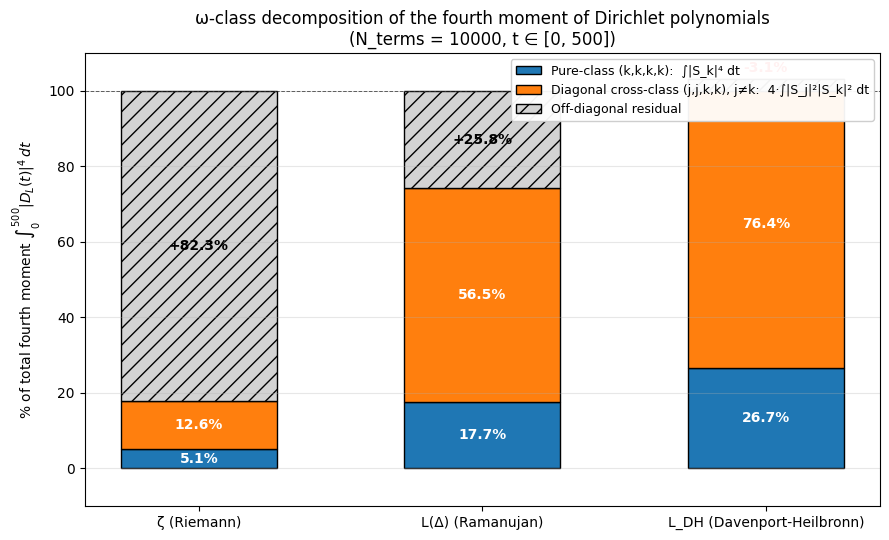

Figure saved.


In [21]:

# The structural patterns are very different across the three L-functions.
# Now create the final summary figure.
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5.5))

labels = ['ζ (Riemann)', 'L(Δ) (Ramanujan)', 'L_DH (Davenport-Heilbronn)']
totals = [tot_z, tot_d, tot_dh]
pures = [sum(pur_z.values()), sum(pur_d.values()), sum(pur_dh.values())]
crosses = [4*sum(cr_z.values()), 4*sum(cr_d.values()), 4*sum(cr_dh.values())]
offdiags = [t - p - c for t, p, c in zip(totals, pures, crosses)]

frac_pure = [100*p/t for p, t in zip(pures, totals)]
frac_cross = [100*c/t for c, t in zip(crosses, totals)]
frac_off = [100*o/t for o, t in zip(offdiags, totals)]

x = np.arange(len(labels))
width = 0.55

# stacked bars
b1 = ax.bar(x, frac_pure, width, label='Pure-class (k,k,k,k): ∫|S_k|⁴ dt', color='#1f77b4', edgecolor='black')
b2 = ax.bar(x, frac_cross, width, bottom=frac_pure, label='Diagonal cross-class (j,j,k,k), j≠k: 4·∫|S_j|²|S_k|² dt', color='#ff7f0e', edgecolor='black')
b3 = ax.bar(x, frac_off, width, bottom=[p+c for p,c in zip(frac_pure, frac_cross)], 
 label='Off-diagonal residual', color='#d3d3d3', edgecolor='black', hatch='//')

ax.axhline(100, color='k', lw=0.7, ls='--', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% of total fourth moment $\\int_0^{500} |D_L(t)|^4\\, dt$')
ax.set_title(f'ω-class decomposition of the fourth moment of Dirichlet polynomials\n(N_terms = {N_terms}, t ∈ [0, 500])')
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
# Annotate values
for i, (p, c, o) in enumerate(zip(frac_pure, frac_cross, frac_off)):
 ax.text(i, p/2, f'{p:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
 ax.text(i, p + c/2, f'{c:.1f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
 ytxt = p + c + o/2 if o > 5 else p + c + 3
 color = 'black' if o > 0 else 'red'
 ax.text(i, ytxt, f'{o:+.1f}%', ha='center', va='center', color=color, fontsize=10, fontweight='bold')
ax.set_ylim(-10, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fourth_moment_omega_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [22]:

# Save tabular results to disk
import json
out = {
 "config": {"N_terms": N_terms, "T_start": 0.0, "T_end": 500.0, "dt": 0.01,
 "classes": classes, "decomposition_definition": {
 "pure_class_(k,k,k,k)": "sum_k ∫|S_k|^4 dt",
 "diagonal_cross_class_(j,j,k,k)": "4 * sum_{j<k} ∫|S_j|^2 |S_k|^2 dt (combinatorial factor 4 from ordered (j1,j2,k1,k2) tuples with positive multiset = negative multiset = {j,k})",
 "off_diagonal_residual": "total - pure - diagonal_cross"
 }},
 "results": {}
}
for label, tot, pur, cr in [("zeta", tot_z, pur_z, cr_z), ("L_Delta", tot_d, pur_d, cr_d), ("L_DH", tot_dh, pur_dh, cr_dh)]:
 sp = sum(pur.values()); sc = sum(cr.values())
 out["results"][label] = {
 "int_abs_D_pow4": float(tot),
 "int_pure_per_class_k": {str(k): float(pur[k]) for k in classes},
 "int_diag_cross_per_pair_jk": {f"{j},{k}": float(cr[(j,k)]) for (j,k) in cr},
 "fraction_pure_pct": float(100*sp/tot),
 "fraction_diag_cross_x4_pct": float(100*4*sc/tot),
 "fraction_off_diag_pct": float(100*(tot - sp - 4*sc)/tot),
 }

with open('fourth_moment_omega_decomposition.json', 'w') as f:
 json.dump(out, f, indent=2)
print("Saved JSON")
# Also save a comparative CSV
import csv
with open('fourth_moment_omega_decomposition_summary.csv', 'w', newline='') as f:
 w = csv.writer(f)
 w.writerow(['L-function', 'int|D|^4 dt [0,500]', 'pure-class (k,k,k,k) %', 'diag cross (j,j,k,k) %', 'sum diag %', 'off-diag %'])
 for label, tot, pur, cr in [("zeta", tot_z, pur_z, cr_z), ("L(Delta)", tot_d, pur_d, cr_d), ("L_DH", tot_dh, pur_dh, cr_dh)]:
 sp = sum(pur.values()); sc = sum(cr.values())
 w.writerow([label, f"{tot:.6e}", f"{100*sp/tot:.4f}", f"{100*4*sc/tot:.4f}", f"{100*(sp+4*sc)/tot:.4f}", f"{100*(tot-sp-4*sc)/tot:.4f}"])
print("Saved CSV")
print(open('fourth_moment_omega_decomposition_summary.csv').read())

Saved JSON
Saved CSV
L-function,"int|D|^4 dt [0,500]","pure-class (k,k,k,k) %","diag cross (j,j,k,k) %",sum diag %,off-diag %
zeta,6.278246e+08,5.1000,12.6425,17.7424,82.2576
L(Delta),3.303673e+04,17.6619,56.5341,74.1960,25.8040
L_DH,1.609392e+04,26.6528,76.4081,103.0609,-3.0609

